In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import json
from glob import glob
import pickle
from tqdm import tqdm
import time
import h5py
import cv2
from contextlib import ExitStack
import openslide

In [2]:
from his_pipeline import Pathological

In [3]:
pipeline = Pathological(config_path='config/config_pipeline.json')

Load Model FastFlow
Load Model Palette


# pipeline

dict_keys(['image', 'anomaly_map', 'pred_label', 'background', 'background_label', 'mask', 'restore'])


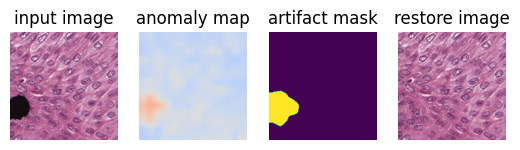

The image is detected as an artifact:  True


In [6]:
colormap = 'coolwarm'
image_path = './data/sample_patch/artifact_1.png'
result = pipeline.pipeline(image_path=image_path)
print(result.keys())
plt.figure()
plt.subplot(141), plt.imshow(result['image']), plt.title('input image'), plt.axis('off')
plt.subplot(142), plt.imshow(result['anomaly_map'], cmap=colormap, vmin=0, vmax=1), plt.title('anomaly map'), plt.axis('off')
plt.subplot(143), plt.imshow(result['mask']), plt.title('artifact mask'), plt.axis('off')
plt.subplot(144), plt.imshow(result['restore']), plt.title('restore image'), plt.axis('off')
plt.show()
print('The image is detected as an artifact: ', result['pred_label'])

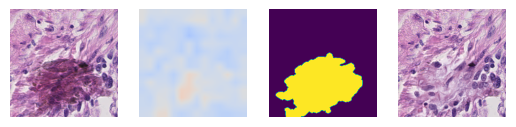

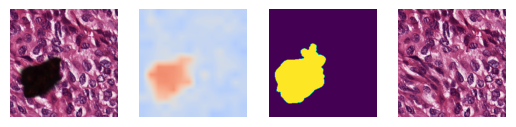

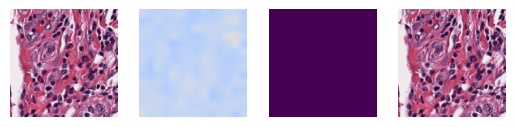

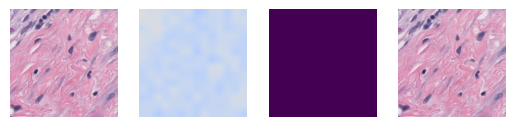

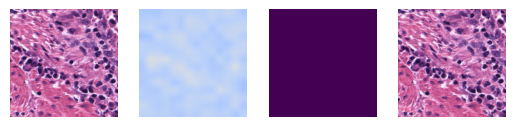

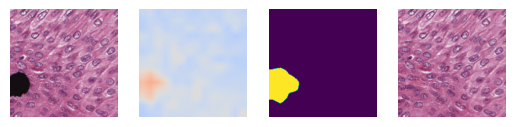

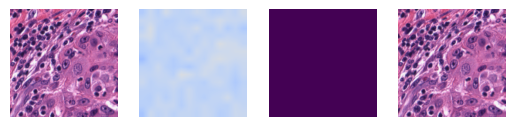

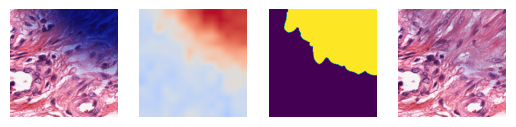

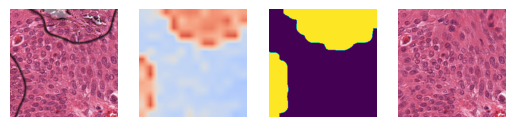

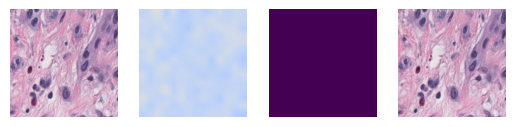

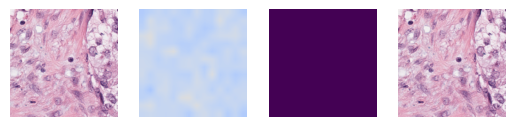

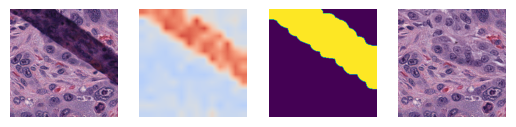

In [8]:
colormap = 'coolwarm'
imgs = glob('./data/sample_patch/*.png')
for image_path in imgs:
    result = pipeline.pipeline(image_path=image_path)
    plt.figure()
    plt.subplot(141), plt.imshow(result['image']), plt.axis('off')
    plt.subplot(142), plt.imshow(result['anomaly_map'], cmap=colormap, vmin=0, vmax=1), plt.axis('off')
    plt.subplot(143), plt.imshow(result['mask']), plt.axis('off')
    plt.subplot(144), plt.imshow(result['restore']), plt.axis('off')
    plt.show()

# detect

dict_keys(['image', 'anomaly_map', 'pred_label'])


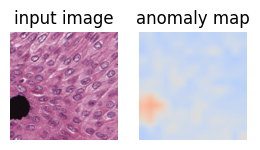

In [7]:
colormap = 'coolwarm'
image_path = './data/sample_patch/artifact_1.png'
result = pipeline.detect(image_path=image_path)
print(result.keys())
plt.figure()
plt.subplot(141), plt.imshow(result['image']), plt.title('input image'), plt.axis('off')
plt.subplot(142), plt.imshow(result['anomaly_map'], cmap=colormap, vmin=0, vmax=1), plt.title('anomaly map'), plt.axis('off')
plt.show()

# locate

dict_keys(['image', 'anomaly_map', 'pred_label', 'mask'])


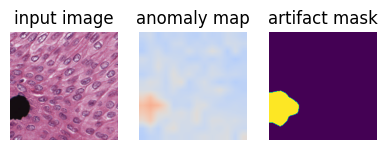

In [8]:
colormap = 'coolwarm'
image_path = './data/sample_patch/artifact_1.png'
result = pipeline.detect(image_path=image_path)
result = pipeline.locate(image=result['image'], anomaly_map=result['anomaly_map'])
print(result.keys())
plt.figure()
plt.subplot(141), plt.imshow(result['image']), plt.title('input image'), plt.axis('off')
plt.subplot(142), plt.imshow(result['anomaly_map'], cmap=colormap, vmin=0, vmax=1), plt.title('anomaly map'), plt.axis('off')
plt.subplot(143), plt.imshow(result['mask']), plt.title('artifact mask'), plt.axis('off')
plt.show()

# restore

dict_keys(['image', 'anomaly_map', 'pred_label', 'mask'])
dict_keys(['image', 'mask', 'restore'])


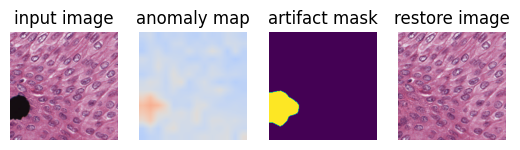

In [9]:
colormap = 'coolwarm'
image_path = './data/sample_patch/artifact_1.png'
result = pipeline.detect(image_path=image_path)
result = pipeline.locate(image=result['image'], anomaly_map=result['anomaly_map'])
result_restore = pipeline.restore(image=result['image'], mask=result['mask'])
print(result.keys())
print(result_restore.keys())
plt.figure()
plt.subplot(141), plt.imshow(result['image']), plt.title('input image'), plt.axis('off')
plt.subplot(142), plt.imshow(result['anomaly_map'], cmap=colormap, vmin=0, vmax=1), plt.title('anomaly map'), plt.axis('off')
plt.subplot(143), plt.imshow(result['mask']), plt.title('artifact mask'), plt.axis('off')
plt.subplot(144), plt.imshow(result_restore['restore']), plt.title('restore image'), plt.axis('off')
plt.show()

# wsi roi sample

In [10]:
def draw_patch_grid(
    img, 
    patch_coords,  #  [(x1,y1), (x2,y2), ...]
    patch_size,          # (w, h)
    color = (0, 255, 0),  # BGR
    thickness = 2
) -> np.ndarray:

    h_img, w_img = img.shape[:2]
    w_patch, h_patch = patch_size

    for (x, y) in patch_coords:
        x2 = x + w_patch
        y2 = y + h_patch
        x2 = min(x2, w_img)
        y2 = min(y2, h_img)
        cv2.rectangle(img, (x, y), (x2, y2), color, thickness)
    return img

def create_mask_overlay(image, mask, alpha=0.5, color_map='coolwarm'):
    """
    image -- image as a numpy array
    mask -- segmentation mask
    alpha -- mask transparency in [0, 1]
    color_map -- colormap used for multi-class masks
    """
    if image.ndim == 2:
        image = np.stack([image]*3, axis=-1)
    elif image.shape[-1] == 1:
        image = np.concatenate([image]*3, axis=-1)
    
    if image.dtype == np.uint8:
        image = image.astype(np.float32) / 255.0
    else:
        image = exposure.rescale_intensity(image, out_range=(0, 1))
    
    if mask.ndim == 3:
        mask = mask[...,0]
    
    if np.issubdtype(mask.dtype, np.bool_) or mask.max() <= 1: 
        colored_mask = np.zeros_like(image)        
        colored_mask[mask > 0] = [1.0, 0.0, 0.0]
    else:  
        cmap = plt.get_cmap(color_map)
        norm = mcolors.Normalize(vmin=mask.min(), vmax=mask.max())
        colored_mask = cmap(norm(mask))[..., :3]  

    overlay = image * (1-mask[:,:,np.newaxis]) + image * (mask[:,:,np.newaxis]) * alpha + colored_mask * alpha
    from skimage.filters import sobel
    edges = sobel(mask.astype(float)) > 0.05
    overlay[edges] = [117/255, 189/255, 66/255]  

    
    return np.clip(overlay, 0, 1)

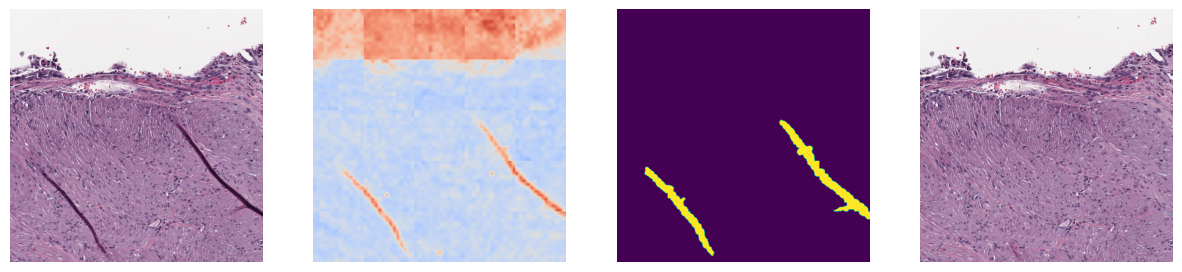

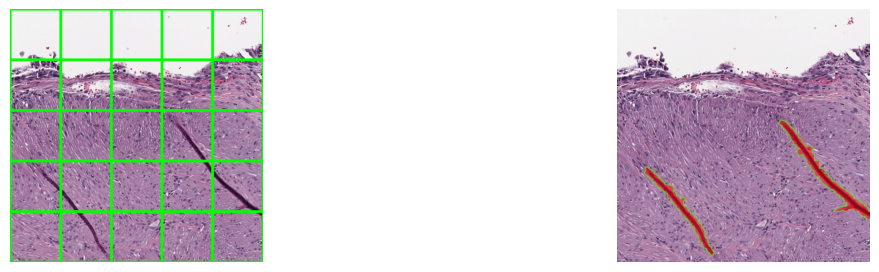

In [16]:
paths = {
    'img': './data/sample_wsi_roi/img.tiff',
    'map': './data/sample_wsi_roi/map.tiff',
    'mask': './data/sample_wsi_roi/mask.tiff',
    'restore': './data/sample_wsi_roi/restore.tiff',
}
with ExitStack() as stack:
    slides = {k: stack.enter_context(openslide.OpenSlide(p)) for k, p in paths.items()}
    
    img = slides['img'].get_thumbnail(slides['img'].level_dimensions[2])
    map_ = slides['map'].get_thumbnail(slides['map'].level_dimensions[2])
    mask = slides['mask'].get_thumbnail(slides['mask'].level_dimensions[2]).convert('L')
    restore = slides['restore'].get_thumbnail(slides['restore'].level_dimensions[2])
    
    plt.figure(figsize=(15,15))
    plt.subplot(141), plt.imshow(img), plt.axis('off')
    plt.subplot(142), plt.imshow(map_.convert('L'), cmap='coolwarm', vmin=0, vmax=255), plt.axis('off')
    plt.subplot(143), plt.imshow(mask), plt.axis('off')
    plt.subplot(144), plt.imshow(restore), plt.axis('off')
    plt.show()

    coord_path = './data/sample_wsi_roi/coords.h5'
    with h5py.File(coord_path,'r') as f:
        patch_coords = [(x//4, y//4) for x, y in f['coords']]

    img_coords = draw_patch_grid(np.array(img), patch_coords, (512//4, 512//4), thickness=5)
    img_overlap_mask = create_mask_overlay(np.array(img), np.array(mask) / 255, alpha=0.5, color_map='coolwarm')
    plt.figure(figsize=(15,15))
    plt.subplot(141), plt.imshow(img_coords), plt.axis('off')
    plt.subplot(143), plt.imshow(img_overlap_mask), plt.axis('off')
    plt.show()